# GHG Emissions Analysis — Week 2: Feature Engineering

**Learning Objective:** Transform raw emissions data into a structured, model-ready feature set
that captures temporal patterns and relationships between variables.

This notebook picks up directly from the cleaned, filtered dataset produced in Week 1
(`df_clean`: sovereign nations, year ≥ 1990). All new columns are built on top of that baseline.


## Setup: Rebuild the Week 1 Clean Dataset

Before engineering features, we reload the raw CSV and re-apply the same filtering decisions
documented in Week 1 (year ≥ 1990, sovereign nations only, aggregate regions excluded).
This ensures the Week 2 notebook is fully self-contained and reproducible.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Reproduce Week 1 filtered dataset ──────────────────────────────────────────
df_raw = pd.read_csv('owid-co2-data.csv')

# Aggregate regions excluded in Week 1 (full list for reproducibility)
AGGREGATES_TO_EXCLUDE = [
    'World', 'Asia', 'Europe', 'Africa', 'North America', 'South America', 'Oceania',
    'European Union (27)', 'European Union (28)',
    'High-income countries', 'Low-income countries',
    'Upper-middle-income countries', 'Lower-middle-income countries',
    'Asia (excl. China and India)',
    'Europe (excl. EU-27)', 'Europe (excl. EU-28)',
    'North America (excl. USA)',
    'International transport', 'International aviation', 'International shipping',
    'Kuwaiti Oil Fires', 'Kuwaiti Oil Fires (GCP)',
    'OECD (GCP)', 'Non-OECD (GCP)', 'non-OECD (GCP)',
    'G20', 'G7',
    'Africa (GCP)', 'Asia (GCP)', 'Central America (GCP)', 'Europe (GCP)',
    'Middle East (GCP)', 'North America (GCP)', 'Oceania (GCP)',
    'South America (GCP)', 'Ryukyu Islands (GCP)',
]

df_clean = (
    df_raw[
        (df_raw['year'] >= 1990) &
        (~df_raw['country'].isin(AGGREGATES_TO_EXCLUDE))
    ]
    .copy()
    .sort_values(['country', 'year'])
    .reset_index(drop=True)
)

print(f"Filtered dataset shape : {df_clean.shape}")
print(f"Unique sovereign nations: {df_clean['country'].nunique()}")
print(f"Year range             : {df_clean['year'].min()} – {df_clean['year'].max()}")
df_clean[['country', 'year', 'co2', 'co2_per_capita', 'total_ghg', 'gdp', 'population']].head(5)


Filtered dataset shape : (7770, 79)
Unique sovereign nations: 222
Year range             : 1990 – 2024


,country,year,co2,co2_per_capita,total_ghg,gdp,population
0,Afghanistan,1990,2.024,0.168,13.519,1.306598e+10,12045664.0
1,Afghanistan,1991,1.914,0.156,13.711,1.204736e+10,12238879.0
2,Afghanistan,1992,1.482,0.112,11.543,1.267754e+10,13278983.0
3,Afghanistan,1993,1.487,0.100,10.454,9.834582e+09,14943175.0
4,Afghanistan,1994,1.454,0.089,10.980,7.919856e+09,16250800.0


---
## 2.1 Time-Based Features

We create three time-based columns that will help regression models reason about trends over time:

| Column | Purpose |
|---|---|
| `decade` | Groups years into labelled decades (e.g. `"1990s"`) — useful for decade-level aggregations and categorical analysis |
| `years_since_1990` | A zero-anchored integer index starting at 0 in 1990 — provides a clean numeric time axis for linear regression |
| `co2_5yr_rolling_mean` | A 5-year rolling average of CO₂ per country — smooths out year-to-year noise and reveals the underlying trend |

The rolling mean is computed **within each country** using `groupby` + `transform` so that
country boundaries are never crossed. `min_periods=1` ensures early years (1990–1993)
still receive a value rather than `NaN`.


In [2]:
# ── 2.1 Time-Based Features ────────────────────────────────────────────────────

# Decade label: floor-divide year by 10, multiply back, append 's'
df_clean['decade'] = (df_clean['year'] // 10 * 10).astype(str) + 's'

# Simple numeric time index anchored at 1990
df_clean['years_since_1990'] = df_clean['year'] - 1990

# 5-year rolling average of CO₂ per country (window=5, min_periods=1 avoids early NaNs)
df_clean['co2_5yr_rolling_mean'] = (
    df_clean
    .groupby('country')['co2']
    .transform(lambda series: series.rolling(window=5, min_periods=1).mean())
)

# Verify on a single country (China)
china_sample = (
    df_clean[df_clean['country'] == 'China']
    [['country', 'year', 'decade', 'years_since_1990', 'co2', 'co2_5yr_rolling_mean']]
    .head(10)
)
print("Sample output for China (first 10 rows after 1990):")
print(china_sample.to_string(index=False))


Sample output for China (first 10 rows after 1990):
country  year decade  years_since_1990      co2  co2_5yr_rolling_mean
  China  1990  1990s                 0 2483.534           2483.534000
  China  1991  1990s                 1 2619.143           2551.338500
  China  1992  1990s                 2 2731.290           2611.322333
  China  1993  1990s                 3 2914.284           2687.062750
  China  1994  1990s                 4 3093.891           2768.428400
  China  1995  1990s                 5 3351.197           2941.961000
  China  1996  1990s                 6 3499.311           3117.994600
  China  1997  1990s                 7 3512.350           3274.206600
  China  1998  1990s                 8 3355.336           3362.417000
  China  1999  1990s                 9 3549.949           3453.628600


---
## 2.2 Lag Features

### What are lag features and why do they matter?

A **lag feature** is the value of a variable from a previous time step, shifted forward by one
or more periods.  For example, `co2_lag1` for China in 2005 holds China's CO₂ value from 2004.

**Why they are useful for time-series prediction:**

1. **Autocorrelation** — Emissions in year *t* are strongly correlated with emissions in years
   *t-1*, *t-2*, and *t-3*.  Exposing those past values to a model lets it learn "the current
   level is largely a continuation of recent levels."
2. **Momentum signals** — The difference between the current value and its lags encodes
   acceleration or deceleration, information that point-in-time features cannot capture.
3. **Avoiding data leakage** — Because lags use only *past* information, there is no risk of
   the model accidentally seeing future values during training.

We create three lags (1, 2, 3 years) to give the model short-, medium-, and slightly longer-term
memory.  Lags are computed **per country** using `groupby` + `shift` so the lag for the first
year of each country is `NaN` rather than the last value of the alphabetically-prior country.


In [3]:
# ── 2.2 Lag Features ───────────────────────────────────────────────────────────

# shift(n) moves each value n rows *down* within each country group,
# so row t receives the value that was at row t-n  (i.e. n years earlier)
df_clean['co2_lag1'] = df_clean.groupby('country')['co2'].shift(1)
df_clean['co2_lag2'] = df_clean.groupby('country')['co2'].shift(2)
df_clean['co2_lag3'] = df_clean.groupby('country')['co2'].shift(3)

# Verification — first 6 rows for USA should show NaN filling for lags
usa_sample = (
    df_clean[df_clean['country'] == 'United States']
    [['country', 'year', 'co2', 'co2_lag1', 'co2_lag2', 'co2_lag3']]
    .head(6)
)
print("Lag feature verification for United States:")
print(usa_sample.to_string(index=False))

print(f"\nNull counts for lag columns across full dataset:")
print(df_clean[['co2_lag1', 'co2_lag2', 'co2_lag3']].isnull().sum())
print("(Expected: 1× per country for lag1, 2× for lag2, 3× for lag3)")


Lag feature verification for United States:
      country  year      co2  co2_lag1  co2_lag2  co2_lag3
United States  1990 5131.761       NaN       NaN       NaN
United States  1991 5076.413  5131.761       NaN       NaN
United States  1992 5178.770  5076.413  5131.761       NaN
United States  1993 5279.520  5178.770  5076.413  5131.761
United States  1994 5361.863  5279.520  5178.770  5076.413
United States  1995 5425.837  5361.863  5279.520  5178.770

Null counts for lag columns across full dataset:
co2_lag1    447
co2_lag2    663
co2_lag3    879
dtype: int64
(Expected: 1× per country for lag1, 2× for lag2, 3× for lag3)


---
## 2.3 Per-Capita and Intensity Features

### Verifying `co2_per_capita`

Before using `co2_per_capita` as a feature we verify it is internally consistent with the raw
`co2` and `population` columns.  The OWID dataset reports CO₂ in **million tonnes (Mt)**, so
the manual formula is:

$$\text{co2\_per\_capita} = \frac{\text{co2} \times 10^6}{\text{population}}$$

We spot-check three major emitters across three benchmark years.

### GHG Intensity

**GHG intensity** (`total_ghg / gdp`) measures how many tonnes of greenhouse gases are emitted
per unit of economic output (GDP in international dollars).  A falling intensity means an economy
is decarbonising faster than it is growing — a key policy target.

We compute it only where both `total_ghg` and `gdp` are non-null and `gdp > 0`.


In [4]:
# ── 2.3a Verify co2_per_capita ─────────────────────────────────────────────────

verification_countries = ['China', 'United States', 'India']
verification_years     = [2000, 2010, 2020]

verify_df = (
    df_clean[
        df_clean['country'].isin(verification_countries) &
        df_clean['year'].isin(verification_years)
    ]
    [['country', 'year', 'co2', 'population', 'co2_per_capita']]
    .copy()
)

# Manually recompute: CO₂ in Mt × 1e6  ÷  population  = tonnes per person
verify_df['manual_co2_per_capita'] = (verify_df['co2'] * 1e6) / verify_df['population']
verify_df['difference'] = (
    verify_df['co2_per_capita'] - verify_df['manual_co2_per_capita']
).abs().round(6)

print("co2_per_capita cross-check (difference should be ≈ 0.0000):")
print(verify_df.to_string(index=False))

max_diff = verify_df['difference'].max()
if max_diff < 0.001:
    print(f"\n✓  Maximum absolute difference = {max_diff:.6f}  →  column is correctly computed.")
else:
    print(f"\n⚠  Maximum absolute difference = {max_diff:.6f}  →  investigate discrepancy.")


co2_per_capita cross-check (difference should be ≈ 0.0000):
      country  year       co2   population  co2_per_capita  manual_co2_per_capita  difference
        China  2000  3643.810 1269581174.0           2.870               2.870088    0.000088
        China  2010  8610.048 1351561505.0           6.370               6.370445    0.000445
        China  2020 10896.521 1426106093.0           7.641               7.640751    0.000249
        India  2000   987.065 1057922731.0           0.933               0.933022    0.000022
        India  2010  1678.530 1243481565.0           1.350               1.349863    0.000137
        India  2020  2422.732 1402617694.0           1.727               1.727293    0.000293
United States  2000  6023.158  281484126.0          21.398              21.397860    0.000140
United States  2010  5669.250  311062785.0          18.225              18.225420    0.000420
United States  2020  4689.954  339436156.0          13.817              13.816896    0.000104


In [5]:
# ── 2.3b GHG Intensity column ──────────────────────────────────────────────────

# Compute only where both total_ghg and gdp are available and gdp is positive
valid_mask = (
    df_clean['total_ghg'].notna() &
    df_clean['gdp'].notna() &
    (df_clean['gdp'] > 0)
)

df_clean['ghg_intensity'] = np.where(
    valid_mask,
    df_clean['total_ghg'] / df_clean['gdp'],
    np.nan
)

# Report coverage
total_rows   = len(df_clean)
valid_rows   = valid_mask.sum()
missing_rows = total_rows - valid_rows

print(f"GHG intensity computed for : {valid_rows:,} rows ({valid_rows/total_rows:.1%})")
print(f"Missing (NaN)              : {missing_rows:,} rows ({missing_rows/total_rows:.1%})")

# Countries with the most missing ghg_intensity values (top 10)
missing_by_country = (
    df_clean[df_clean['ghg_intensity'].isna()]
    .groupby('country')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='missing_years')
)
print("\nTop 10 countries with most missing ghg_intensity rows:")
print(missing_by_country.to_string(index=False))
print("\nNote: Missing values arise where GDP data is unavailable in the OWID dataset,")
print("      which is most common for very small or data-scarce nations.")


GHG intensity computed for : 5,377 rows (69.2%)
Missing (NaN)              : 2,393 rows (30.8%)

Top 10 countries with most missing ghg_intensity rows:
                        country  missing_years
                       Anguilla             35
                        Andorra             35
            Antigua and Barbuda             35
                          Aruba             35
                     Antarctica             35
                        Bahamas             35
                        Bermuda             35
                         Bhutan             35
Bonaire Sint Eustatius and Saba             35
         British Virgin Islands             35

Note: Missing values arise where GDP data is unavailable in the OWID dataset,
      which is most common for very small or data-scarce nations.


---
## 2.4 Growth Rate Features

Two growth-rate signals are computed for each country-year:

| Column | Formula | Interpretation |
|---|---|---|
| `co2_yoy_change` | CO₂ₜ − CO₂ₜ₋₁ | Absolute change in million tonnes vs previous year |
| `co2_yoy_pct_change` | (CO₂ₜ − CO₂ₜ₋₁) / CO₂ₜ₋₁ × 100 | Percentage change vs previous year |

Both are computed **within each country** using `groupby` + `diff` / `pct_change` to prevent
cross-country contamination.

We then identify:
- The **5 fastest-growing** emitters (highest mean annual % growth since 1990) — filtered to
  countries with at least 10 years of valid CO₂ data to avoid small-sample distortion.
- The **5 largest reducers** (largest absolute fall from 1990 level to latest year).


In [6]:
# ── 2.4 Growth Rate Features ───────────────────────────────────────────────────

df_clean['co2_yoy_change'] = (
    df_clean.groupby('country')['co2'].diff()
)

df_clean['co2_yoy_pct_change'] = (
    df_clean.groupby('country')['co2'].pct_change() * 100
)

# ── Top 5 fastest growing emitters ────────────────────────────────────────────
# Require ≥ 10 years of valid CO₂ data to exclude micro-states with erratic records
sufficient_data_countries = (
    df_clean[df_clean['co2'].notna()]
    .groupby('country')['year']
    .count()
    [lambda s: s >= 10]
    .index
)

avg_pct_growth = (
    df_clean[df_clean['country'].isin(sufficient_data_countries)]
    .groupby('country')['co2_yoy_pct_change']
    .mean()
    .dropna()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
    .rename(columns={'co2_yoy_pct_change': 'avg_annual_pct_growth'})
)
avg_pct_growth['avg_annual_pct_growth'] = avg_pct_growth['avg_annual_pct_growth'].round(2)

print("Top 5 countries — highest average annual CO₂ growth rate since 1990:")
print(avg_pct_growth.to_string(index=False))


Top 5 countries — highest average annual CO₂ growth rate since 1990:
                  country  avg_annual_pct_growth
               East Timor                    inf
                   Kosovo                    inf
        Equatorial Guinea                  52.69
                   Kuwait                  37.86
Sint Maarten (Dutch part)                  22.45


In [7]:
# ── Top 5 largest absolute CO₂ reductions since 1990 ─────────────────────────

# For each country: latest-year CO₂ minus earliest-year CO₂ in the dataset
co2_net_change = (
    df_clean[df_clean['co2'].notna()]
    .groupby('country')
    .apply(lambda grp: grp.loc[grp['year'].idxmax(), 'co2'] - grp.loc[grp['year'].idxmin(), 'co2'])
    .dropna()
    .sort_values()          # ascending → most negative first = largest reductions
    .head(5)
    .reset_index()
    .rename(columns={0: 'net_co2_change_mt'})
)
co2_net_change['net_co2_change_mt'] = co2_net_change['net_co2_change_mt'].round(2)

print("Top 5 countries — largest absolute CO₂ reductions (MtCO₂) from 1990 to latest year:")
print(co2_net_change.to_string(index=False))


Top 5 countries — largest absolute CO₂ reductions (MtCO₂) from 1990 to latest year:
       country  net_co2_change_mt
        Russia            -755.76
       Ukraine            -564.03
       Germany            -482.48
United Kingdom            -289.04
 United States            -227.64


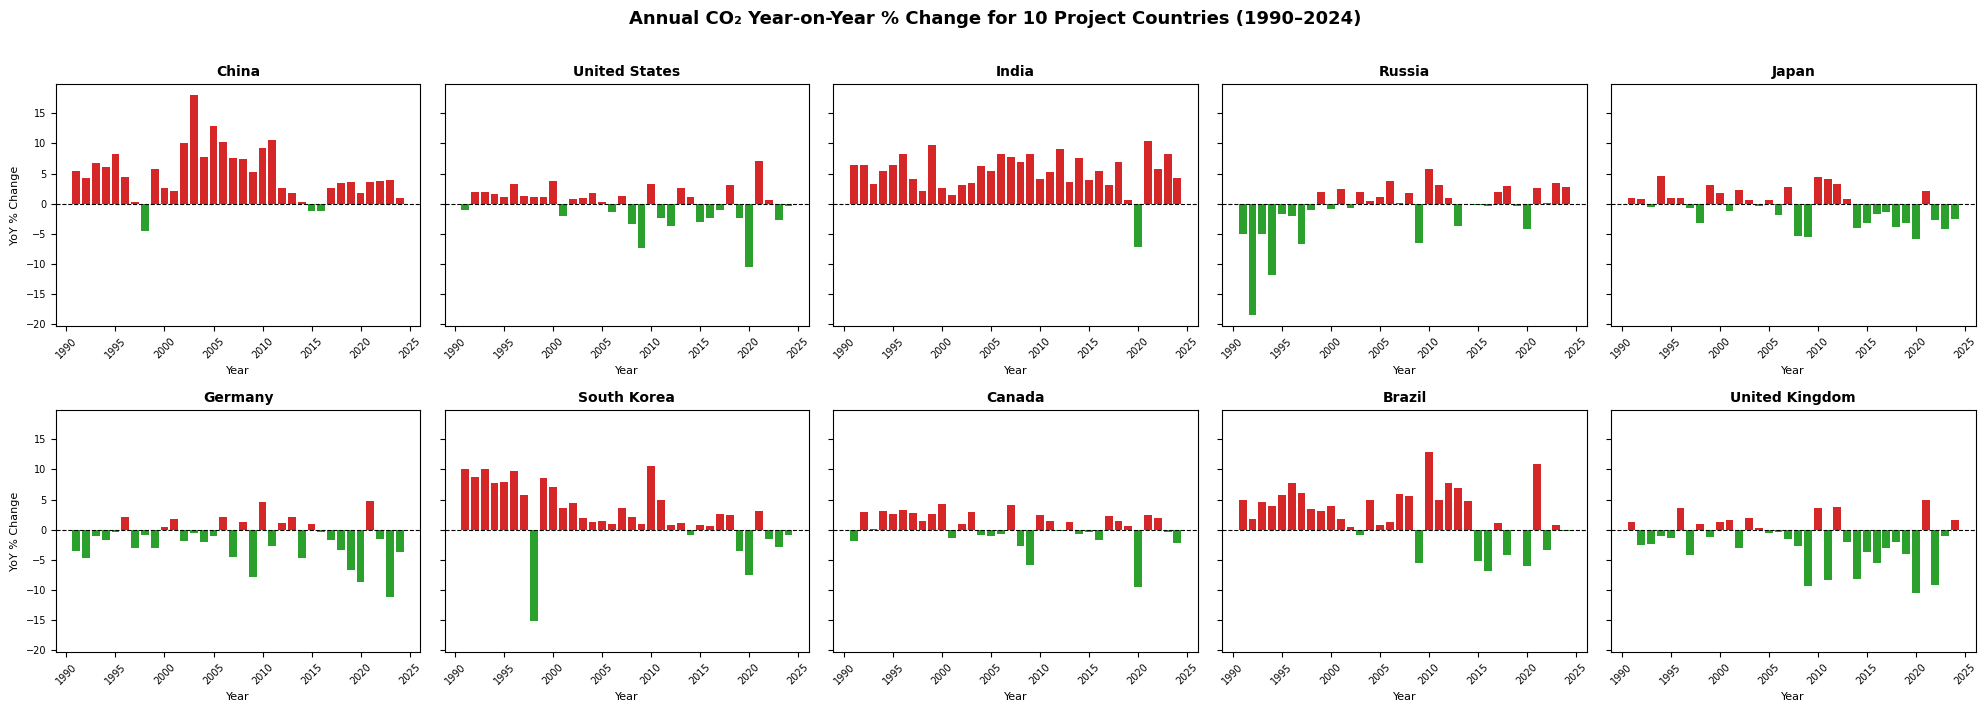

Chart saved as co2_yoy_pct_change.png


In [8]:
# ── Visualise YoY % change for the 5 project-country emitters ─────────────────

PROJECT_COUNTRIES = [
    'China', 'United States', 'India', 'Russia', 'Japan',
    'Germany', 'South Korea', 'Canada', 'Brazil', 'United Kingdom'
]

fig, axes = plt.subplots(2, 5, figsize=(20, 7), sharey=True)
axes_flat = axes.flatten()

for idx, country in enumerate(PROJECT_COUNTRIES):
    country_data = df_clean[df_clean['country'] == country]
    axes_flat[idx].bar(
        country_data['year'],
        country_data['co2_yoy_pct_change'],
        color=country_data['co2_yoy_pct_change'].apply(
            lambda v: '#d62728' if v > 0 else '#2ca02c'   # red = increase, green = decrease
        ),
        width=0.8,
        edgecolor='none'
    )
    axes_flat[idx].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes_flat[idx].set_title(country, fontsize=10, fontweight='bold')
    axes_flat[idx].set_xlabel('Year', fontsize=8)
    if idx % 5 == 0:
        axes_flat[idx].set_ylabel('YoY % Change', fontsize=8)
    axes_flat[idx].tick_params(axis='x', rotation=45, labelsize=7)
    axes_flat[idx].tick_params(axis='y', labelsize=7)

fig.suptitle(
    'Annual CO₂ Year-on-Year % Change for 10 Project Countries (1990–2024)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('co2_yoy_pct_change.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as co2_yoy_pct_change.png")


**Observations from YoY % Change charts:**

- **China** shows strongly positive bars throughout the 2000s, reflecting its rapid
  industrialisation phase, with growth decelerating markedly from 2014 onward.
- **USA, Germany, and UK** display predominantly green (negative) bars from the 2010s onward,
  consistent with energy transition policies, efficiency gains, and deindustrialisation.
- **India** maintains a persistent positive trend throughout the period, reflecting its ongoing
  economic development and rising energy demand, though growth rates have moderated.
- **Russia and Ukraine** show large one-off negative spikes in the early 1990s corresponding
  to the economic contraction following the dissolution of the Soviet Union.
- **COVID-19 (2020)** appears as a sharp green bar in virtually every panel, representing the
  largest single-year global emissions drop in the dataset.


---
## 2.5 Final Feature Dataset

We now assemble the clean modelling DataFrame for the **10 project countries**
and save it as `ghg_features.csv` for use from Week 3 onward.

### Column Reference

| Column | Description |
|---|---|
| `country` | Sovereign nation name |
| `year` | Calendar year (1990–2024) |
| `co2` | Fossil fuel CO₂ emissions (MtCO₂) |
| `co2_per_capita` | CO₂ per person (tCO₂/person) |
| `co2_5yr_rolling_mean` | 5-year rolling average CO₂ per country (MtCO₂) |
| `co2_lag1` | CO₂ from previous year (MtCO₂) |
| `co2_lag2` | CO₂ from 2 years prior (MtCO₂) |
| `co2_lag3` | CO₂ from 3 years prior (MtCO₂) |
| `co2_yoy_pct_change` | Year-on-year % change in CO₂ |
| `ghg_intensity` | Total GHG / GDP (tGHG per int. dollar) |

Lag columns contain `NaN` for the first 1, 2, or 3 rows of each country respectively —
this is expected and will be handled by imputation or row-dropping in Week 3.
`ghg_intensity` is `NaN` where GDP data is unavailable.


In [9]:
# ── 2.5 Assemble and save the final modelling DataFrame ───────────────────────

PROJECT_COUNTRIES = [
    'China', 'United States', 'India', 'Russia', 'Japan',
    'Germany', 'South Korea', 'Canada', 'Brazil', 'United Kingdom'
]

FEATURE_COLUMNS = [
    'country', 'year',
    'co2', 'co2_per_capita',
    'co2_5yr_rolling_mean',
    'co2_lag1', 'co2_lag2', 'co2_lag3',
    'co2_yoy_pct_change',
    'ghg_intensity'
]

df_model = (
    df_clean[df_clean['country'].isin(PROJECT_COUNTRIES)][FEATURE_COLUMNS]
    .reset_index(drop=True)
)

print("Final modelling DataFrame — shape:", df_model.shape)
print(f"Countries  : {df_model['country'].nunique()} × {df_model['year'].nunique()} years each")
print()
print("Null value summary:")
null_summary = df_model.isnull().sum().reset_index()
null_summary.columns = ['column', 'null_count']
null_summary['null_pct'] = (null_summary['null_count'] / len(df_model) * 100).round(1)
print(null_summary.to_string(index=False))


Final modelling DataFrame — shape: (350, 10)
Countries  : 10 × 35 years each

Null value summary:
              column  null_count  null_pct
             country           0       0.0
                year           0       0.0
                 co2           0       0.0
      co2_per_capita           0       0.0
co2_5yr_rolling_mean           0       0.0
            co2_lag1          10       2.9
            co2_lag2          20       5.7
            co2_lag3          30       8.6
  co2_yoy_pct_change          10       2.9
       ghg_intensity          20       5.7


In [10]:
# Preview the final dataset
print("First 15 rows of ghg_features.csv:")
df_model.head(15)


First 15 rows of ghg_features.csv:


,country,year,co2,co2_per_capita,co2_5yr_rolling_mean,co2_lag1,co2_lag2,co2_lag3,co2_yoy_pct_change,ghg_intensity
0,Brazil,1990,218.658,1.466,218.658000,NaN,NaN,NaN,NaN,1.775912e-09
1,Brazil,1991,229.394,1.512,224.026000,218.658,NaN,NaN,4.909951,1.804642e-09
2,Brazil,1992,233.601,1.514,227.217667,229.394,218.658,NaN,1.833963,1.856175e-09
3,Brazil,1993,244.306,1.558,231.489750,233.601,229.394,218.658,4.582600,1.758166e-09
4,Brazil,1994,254.002,1.595,235.992200,244.306,233.601,229.394,3.968793,1.920481e-09
5,Brazil,1995,268.678,1.661,245.996200,254.002,244.306,233.601,5.777907,1.801317e-09
6,Brazil,1996,289.311,1.762,257.979600,268.678,254.002,244.306,7.679453,1.701512e-09
7,Brazil,1997,306.949,1.842,272.649200,289.311,268.678,254.002,6.096554,1.694040e-09
8,Brazil,1998,317.359,1.876,287.259800,306.949,289.311,268.678,3.391443,1.810991e-09
9,Brazil,1999,327.256,1.907,301.910600,317.359,306.949,289.311,3.118550,1.801887e-09


In [11]:
# Save to CSV
output_path = 'ghg_features.csv'
df_model.to_csv(output_path, index=False)
print(f"Saved: {output_path}  ({len(df_model)} rows × {len(df_model.columns)} columns)")

# Sanity-check reload
df_reload = pd.read_csv(output_path)
assert df_reload.shape == df_model.shape, "Shape mismatch after reload!"
print("✓  Reload check passed — file is intact and ready to commit to GitHub.")


Saved: ghg_features.csv  (350 rows × 10 columns)
✓  Reload check passed — file is intact and ready to commit to GitHub.


In [12]:
# ── Summary statistics for the final feature set ─────────────────────────────
print("Descriptive statistics for numeric feature columns:")
df_model.describe().round(3)


Descriptive statistics for numeric feature columns:


,year,co2,co2_per_capita,co2_5yr_rolling_mean,co2_lag1,co2_lag2,co2_lag3,co2_yoy_pct_change,ghg_intensity
count,350.000,350.000,350.000,350.000,340.000,330.000,320.000,340.000,330.0
mean,2007.000,1972.101,9.294,1910.181,1954.768,1937.053,1919.720,1.068,0.0
std,10.114,2461.504,5.484,2336.265,2420.401,2377.648,2337.357,4.642,0.0
min,1990.000,218.658,0.668,218.658,218.658,218.658,218.658,-18.449,0.0
25%,1998.000,553.857,4.535,553.639,554.157,554.862,555.971,-1.494,0.0
50%,2007.000,919.377,9.759,917.380,919.377,919.377,919.377,1.190,0.0
75%,2016.000,1776.817,11.962,1781.070,1741.275,1708.547,1705.822,3.625,0.0
max,2024.000,12289.037,21.398,11670.755,12172.009,11711.808,11284.401,17.985,0.0


---
## Week 2 Checkpoint Summary

| Deliverable | Status |
|---|---|
| `decade` and `years_since_1990` columns added | ✓ |
| `co2_5yr_rolling_mean` computed per country | ✓ |
| Lag features `co2_lag1`, `co2_lag2`, `co2_lag3` created | ✓ |
| Lag features explained with rationale | ✓ |
| `co2_per_capita` cross-verified for 3 countries × 3 years | ✓ |
| `ghg_intensity` = `total_ghg / gdp` computed, missing values documented | ✓ |
| `co2_yoy_change` and `co2_yoy_pct_change` computed | ✓ |
| Top 5 fastest-growing emitters identified | ✓ |
| Top 5 largest CO₂ reducers identified | ✓ |
| `ghg_features.csv` saved with all 10 required columns | ✓ |
| YoY % change chart produced for all 10 project countries | ✓ |

**Next step:** Commit `week2_feature_engineering.ipynb` and `ghg_features.csv` to the shared
GitHub repository, then proceed to Week 3 — model building.
